In [2]:
import os, re, glob, random, shutil
from collections import defaultdict

random.seed(42)
SRC = "/kaggle/input/datasets/rahnumatasnim1604103/bangladeshi-banknote-dataset/dataset"
OUT = "/kaggle/working/bdtaka"
TRAIN_PER_CLASS = 300
VAL_PER_CLASS   = 75
BOX_WH = 0.98  

shutil.rmtree(OUT, ignore_errors=True)

by_cls = defaultdict(list)
bad = 0
for p in glob.glob(SRC+"/*.png")+glob.glob(SRC+"/*.jpg")+glob.glob(SRC+"/*.jpeg"):
    m = re.match(r"\s*(\d+)", os.path.basename(p))
    if m: by_cls[int(m.group(1))].append(p)
    else: bad += 1

classes = sorted(by_cls.keys())
names = [f"{c}_taka" for c in classes]
cls_to_idx = {c:i for i,c in enumerate(classes)}
print("\nClasses (idx -> name):", {i:n for i,n in enumerate(names)})

for split in ("train","val"):
    os.makedirs(f"{OUT}/images/{split}", exist_ok=True)
    os.makedirs(f"{OUT}/labels/{split}", exist_ok=True)

def write_label(path, idx):
    open(path,"w").write(f"{idx} 0.5 0.5 {BOX_WH} {BOX_WH}\n")

counts = {"train":0,"val":0}
for c in classes:
    imgs = by_cls[c][:]; random.shuffle(imgs)
    val   = imgs[:VAL_PER_CLASS]
    train = imgs[VAL_PER_CLASS:VAL_PER_CLASS+TRAIN_PER_CLASS]
    for split, group in (("train",train),("val",val)):
        for i, src in enumerate(group):
            stem = f"{c}taka_{split}_{i:04d}"
            shutil.copy(src, f"{OUT}/images/{split}/{stem}.png")
            write_label(f"{OUT}/labels/{split}/{stem}.txt", cls_to_idx[c])
            counts[split]+=1

yaml = f"path: {OUT}\ntrain: images/train\nval: images/val\nnc: {len(classes)}\nnames: {names}\n"
open(f"{OUT}/data.yaml","w").write(yaml)

print("train imgs:", counts["train"], "| val imgs:", counts["val"])
print("data.yaml:\n"+yaml)


Classes (idx -> name): {0: '2_taka', 1: '5_taka', 2: '10_taka', 3: '20_taka', 4: '50_taka', 5: '100_taka', 6: '500_taka', 7: '1000_taka'}
train imgs: 2400 | val imgs: 600
data.yaml:
path: /kaggle/working/bdtaka
train: images/train
val: images/val
nc: 8
names: ['2_taka', '5_taka', '10_taka', '20_taka', '50_taka', '100_taka', '500_taka', '1000_taka']



In [3]:
!pip -q install -U ultralytics
import torch
print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

from ultralytics import YOLO
model = YOLO("yolo11n.pt")          # YOLOv11 nano (detection)
model.train(
    data="/kaggle/working/bdtaka/data.yaml",
    epochs=20, imgsz=416, batch=32, patience=5, seed=42,
    project="/kaggle/working/runs", name="bdtaka", exist_ok=True, verbose=True
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.8 MB/s eta 0:00:00
Torch: 2.10.0+cu128 | CUDA: True
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/bdtaka/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783430a53320>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

Loaded model. Classes: {0: '2_taka', 1: '5_taka', 2: '10_taka', 3: '20_taka', 4: '50_taka', 5: '100_taka', 6: '500_taka', 7: '1000_taka'}

Image: test_2_taka.png  (size=(256, 117))
   -> 2_taka      conf=0.9656  bbox=[0.2, 0.6, 256.0, 117.0]

Image: test_5_taka.png  (size=(256, 117))
   -> 5_taka      conf=0.9468  bbox=[1.8, 0.8, 256.0, 117.0]

Image: test_10_taka.png  (size=(256, 117))
   -> 10_taka     conf=0.9551  bbox=[0.3, 0.6, 254.4, 117.0]

Image: test_20_taka.png  (size=(256, 117))
   -> 20_taka     conf=0.9706  bbox=[1.2, 0.8, 255.7, 117.0]

Image: test_50_taka.png  (size=(256, 117))
   -> 50_taka     conf=0.9779  bbox=[0.2, 0.6, 255.8, 117.0]

Image: test_100_taka.png  (size=(256, 117))
   -> 100_taka    conf=0.9176  bbox=[0.6, 1.5, 256.0, 117.0]

Image: test_500_taka.png  (size=(256, 117))
   -> 500_taka    conf=0.9795  bbox=[0.3, 0.8, 256.0, 117.0]

Image: test_1000_taka.png  (size=(256, 117))
   -> 1000_taka   conf=0.9553  bbox=[1.4, 0.9, 255.4, 117.0]


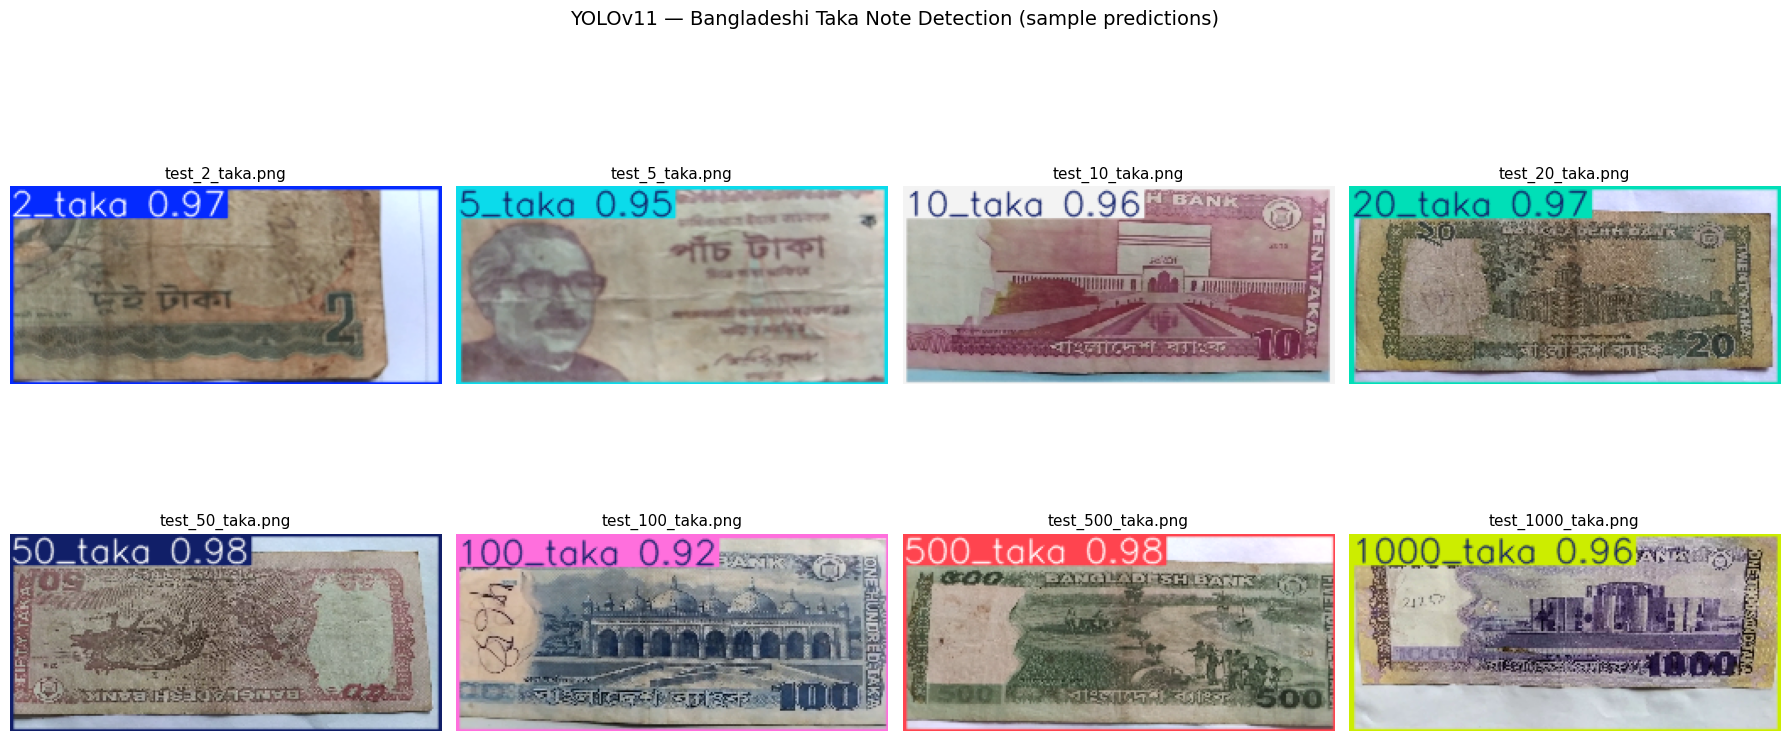

best.pt size: 5.43 MB


/kaggle/working/deliverables.zip

In [4]:
import os, re, glob, random, shutil
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

SRC   = "/kaggle/input/datasets/rahnumatasnim1604103/bangladeshi-banknote-dataset/dataset"
BEST  = "/kaggle/working/runs/bdtaka/weights/best.pt"
TEST  = "/kaggle/working/test_images"
PRED  = "/kaggle/working/predictions"
STAGE = "/kaggle/working/deliverables"
for d in (TEST, PRED):
    shutil.rmtree(d, ignore_errors=True); os.makedirs(d)

random.seed(42)
by_cls = defaultdict(list)
for p in glob.glob(SRC + "/*.png"):
    m = re.match(r"\s*(\d+)", os.path.basename(p))
    if m:
        by_cls[int(m.group(1))].append(p)

classes = sorted(by_cls.keys())        
unseen = {}
for c in classes:
    imgs = by_cls[c][:]; random.shuffle(imgs)
    unseen[c] = imgs[375:]        

model = YOLO(BEST)
print("Loaded model. Classes:", model.names)

test_paths = []
for c in classes:
    dst = os.path.join(TEST, f"test_{c}_taka.png")
    shutil.copy(unseen[c][0], dst)
    test_paths.append(dst)

for tp in test_paths:
    r = model.predict(tp, conf=0.25, verbose=False)[0]
    print(f"\nImage: {os.path.basename(tp)}  (size={Image.open(tp).size})")
    if len(r.boxes) == 0:
        print("   No detections.")
    for b in r.boxes:
        cid = int(b.cls[0]); name = model.names[cid]; conf = float(b.conf[0])
        x1, y1, x2, y2 = [round(float(v), 1) for v in b.xyxy[0].tolist()]
        print(f"   -> {name:10s}  conf={conf:.4f}  bbox=[{x1}, {y1}, {x2}, {y2}]")
    annotated = r.plot()[..., ::-1]
    Image.fromarray(annotated).save(os.path.join(PRED, "pred_" + os.path.basename(tp)))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, tp in zip(axes.ravel(), test_paths):
    ax.imshow(Image.open(os.path.join(PRED, "pred_" + os.path.basename(tp))))
    ax.axis("off"); ax.set_title(os.path.basename(tp), fontsize=11)
plt.suptitle("YOLOv11 — Bangladeshi Taka Note Detection (sample predictions)", fontsize=14)
plt.tight_layout()
plt.savefig("/kaggle/working/phase1_sample_output.png", dpi=120, bbox_inches="tight")
plt.show()

shutil.rmtree(STAGE, ignore_errors=True); os.makedirs(STAGE)
shutil.copy(BEST, os.path.join(STAGE, "best.pt"))
shutil.copytree(TEST, os.path.join(STAGE, "test_images"))
shutil.copytree(PRED, os.path.join(STAGE, "predictions"))
shutil.copy("/kaggle/working/phase1_sample_output.png", STAGE)
shutil.make_archive("/kaggle/working/deliverables", "zip", STAGE)

print("best.pt size:", round(os.path.getsize(BEST) / 1e6, 2), "MB")

from IPython.display import FileLink
FileLink("deliverables.zip")